# **模块**: 编程练习
## **主题**: 基于PLS的加热炉监控

In [1]:
# 导入所需包
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


np.set_printoptions(precision=3, suppress=True)

In [2]:
#%% fetch NOC training data
data_train = pd.read_csv('NoFault_FlowVarying_48HrsData.csv').values
data_train = data_train[:,1:] # first column gives sampling time
X_train, Y_train = data_train[:,0:3], data_train[:,3:]

print('X_train 矩阵形状：', X_train.shape)
print('Y_train 矩阵形状：', Y_train.shape)

X_train 矩阵形状： (2880, 3)
Y_train 矩阵形状： (2880, 5)


In [3]:
# ==================================================================================
#       拟合PLS模型并为训练集生成监控图
# ==================================================================================

In [4]:
n_comp = 2

In [5]:
# 缩放数据
X_scaler = StandardScaler()
Y_scaler = StandardScaler()
X_train_normal = X_scaler.fit_transform(X_train)
Y_train_normal = Y_scaler.fit_transform(Y_train)

pls = PLSRegression(n_components=n_comp)
pls.fit(X_train_normal, Y_train_normal)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](5, 3)","[[-0.34,-0.37,-0.32], [ 0.33, 0.37, 0.31], [ 2.07,-2.12, 0.05], [ 0.62,-0.27, 0.17], [-0.27, 0.64, 0.15]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](5,)","[-0.,-0., 0.,-0., 0.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,3
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,"[3, 17]"
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](3, 2)","[[ 0.58,-0.7 ], [ 0.58, 0.72], [ 0.58,-0.02]]"


In [6]:
# 计算训练样本的T2统计量
Tscores_train = pls.x_scores_

score_variances = np.diag(np.var(Tscores_train, 0, ddof=1)) # ddof=1 for sample variance
score_variances_inv = np.linalg.inv(score_variances)

T2_train = np.zeros((X_train_normal.shape[0],))
for i in range(X_train_normal.shape[0]):
    T2_train[i] = np.dot(np.dot(Tscores_train[i,:], score_variances_inv), Tscores_train[i,:].T)

In [7]:
# 计算训练样本的SPEx与SPEy
# SPEx
X_train_normal_reconstruct = pls.inverse_transform(Tscores_train)
x_error_train = X_train_normal - X_train_normal_reconstruct
SPEx_train = np.sum(x_error_train*x_error_train, axis = 1)

# SPEy
y_error_train = Y_train_normal - pls.predict(X_train_normal)
SPEy_train = np.sum(y_error_train*y_error_train, axis = 1)

In [8]:
# 控制限
T2_CL = np.percentile(T2_train, 99)
SPEx_CL = np.percentile(SPEx_train, 99)
SPEy_CL = np.percentile(SPEy_train, 99)

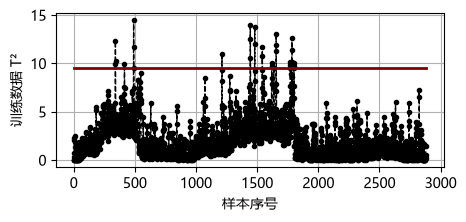

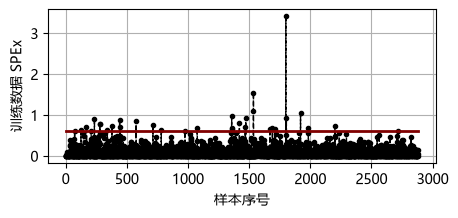

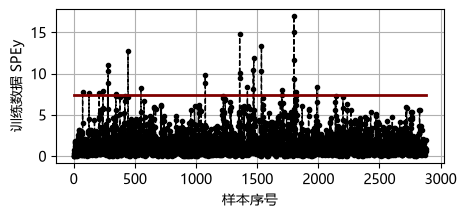

In [9]:
# 训练数据的控制图
# T2_train
plt.figure(figsize=(5,2))
plt.plot(T2_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_train)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()

# SPEx_train
plt.figure(figsize=(5,2))
plt.plot(SPEx_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(SPEx_train)],[SPEx_CL,SPEx_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 SPEx')
plt.grid()

# SPEy_train
plt.figure(figsize=(5,2))
plt.plot(SPEy_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(SPEy_train)],[SPEy_CL,SPEy_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 SPEy')
plt.grid()

plt.show()

In [10]:
##%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                  故障过程运行分析
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [11]:
# 获取测试数据并归一化
data_test = pd.read_csv('TI1_DisturbanceFault_6HrsData.csv').values
data_test = data_test[:,1:] # first column gives sampling time
X_test, Y_test = data_test[:,0:3], data_test[:,3:]

print('X_test 矩阵形状：', X_test.shape)
print('Y_test 矩阵形状：', Y_test.shape)

X_test_normal = X_scaler.transform(X_test)
Y_test_normal = Y_scaler.transform(Y_test)

X_test 矩阵形状： (360, 3)
Y_test 矩阵形状： (360, 5)


In [12]:
# 获取得分与模型预测 
Tscores_test = pls.transform(X_test_normal)
X_test_normal_reconstruct = pls.inverse_transform(Tscores_test)
Y_test_normal_pred = pls.predict(X_test_normal)

In [13]:
# 计算监控统计量
T2_test = np.zeros((X_test_normal.shape[0],))
for i in range(X_test_normal.shape[0]):
    T2_test[i] = np.dot(np.dot(Tscores_test[i,:], score_variances_inv), Tscores_test[i,:].T)

x_error_test = X_test_normal - X_test_normal_reconstruct
SPEx_test = np.sum(x_error_test*x_error_test, axis = 1)

y_error_test = Y_test_normal - Y_test_normal_pred
SPEy_test = np.sum(y_error_test*y_error_test, axis = 1)

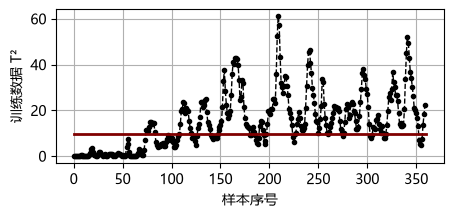

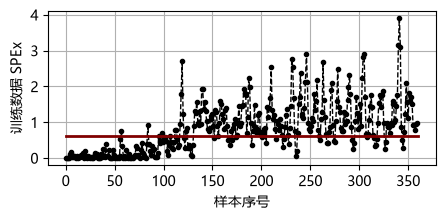

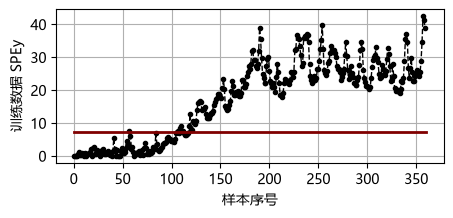

In [14]:
# 绘制完整数据集的控制图
plt.figure(figsize=(5,2))
plt.plot(T2_test, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_test)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()

plt.figure(figsize=(5,2))
plt.plot(SPEx_test, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(SPEx_test)],[SPEx_CL,SPEx_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 SPEx')
plt.grid()

plt.figure(figsize=(5,2))
plt.plot(SPEy_test, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(SPEy_test)],[SPEy_CL,SPEy_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 SPEy')
plt.grid()

plt.show()

In [15]:
##%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                  使用贡献图进行故障隔离
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [16]:
sample = 250

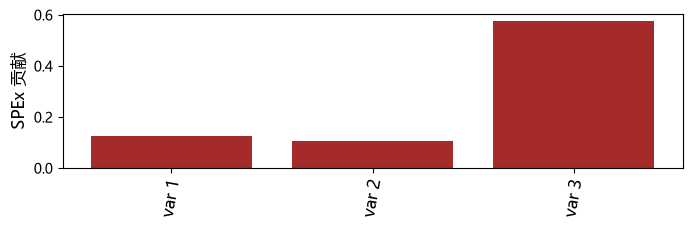

In [17]:
# SPEx贡献图
x_error_test_sample = x_error_test[sample-1,]
SPEx_contri = x_error_test_sample*x_error_test_sample # vector of contributions

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(SPEx_contri))], SPEx_contri, color='brown')
plt.xticks(rotation = 80, fontsize=12)
plt.ylabel('SPEx 贡献', fontsize=12)
plt.show()

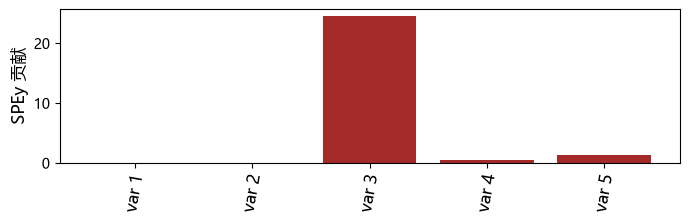

In [18]:
# SPEy贡献图
y_error_sample = y_error_test[sample-1,]
SPEy_contri = y_error_sample*y_error_sample # vector of contributions

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(SPEy_contri))], SPEy_contri, color='brown')
plt.xticks(rotation = 80, fontsize=12)
plt.ylabel('SPEy 贡献', fontsize=12)
plt.show()

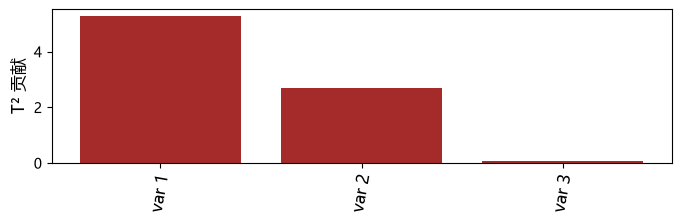

In [19]:
# T2贡献图
import scipy

R = pls.x_rotations_
Ghe = np.dot(scipy.linalg.sqrtm(score_variances_inv), R.T)
x_test_normal_sample = np.transpose(X_test_normal[sample-1,:])

T2_contri = np.zeros((X_test_normal.shape[1],))
for i in range(X_test_normal.shape[1]):
    vect = Ghe[:,i]*x_test_normal_sample[i]
    T2_contri[i] = np.dot(vect, vect)

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(T2_contri))], T2_contri, color='brown')
plt.xticks(rotation = 80, fontsize=12)
plt.ylabel('T² 贡献', fontsize=12)
plt.show()

#### 贡献图似乎未能明确指示哪些变量存在故障。T2贡献图正确捕捉到FC1和FC2行为异常。SPEy贡献图也正确尝试突出受TI1与TI2差异显著影响的DT变量。由于MPC的作用，扰动的影响已扩散到多个变量（三个输入变量均受到影响）！ 